In [2]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FactorAnalysis
from factor_analyzer import FactorAnalyzer
# rd_v4.1_all_openai-2025-02-18_17-50-02_eval_S1

In [3]:
traits = {
    'cOPN': 'Openness',
    'cEXT': 'Extraversion',
    'cNEU': 'Neuroticism',
    'cAGR': 'Agreeableness',	
    'cCON': 'Conscientiousness'
}

In [5]:
df = pd.read_csv('/data/jmharja/projects/PersonaClassifier/checkpoint/rd_v4.1_all_openai-2025-02-18_17-50-02_eval_S1/prediction_test.csv')
edf = pd.read_csv('/data/jmharja/projects/PersonaClassifier/data/pandora_to_big5_openai_embedded.csv' )
liwc_df = pd.read_csv('/data/jmharja/projects/PersonaClassifier/processed_data/LIWC_pandora_to_big5_v4.csv' )
df.shape, edf.shape, liwc_df.shape

/tmp/ipykernel_2821198/807406156.py:2: DtypeWarning: Columns (17,24,25,26,34,40,41,42,49) have mixed types. Specify dtype option on import or set low_memory=False.
  edf = pd.read_csv('/data/jmharja/projects/PersonaClassifier/data/pandora_to_big5_openai_embedded.csv' )


((93511, 18), (935102, 55), (908432, 140))

In [ ]:
for target in traits:
# target = 'cOPN'
    df = pd.read_csv('/data/jmharja/projects/PersonaClassifier/checkpoint/rd_v4.1_all_openai-2025-02-18_17-50-02_eval_S1/prediction_test.csv')
    df = df[df[target]==1]
    df = df[df[f'mlp_{target}'] == 1] 
    df = df[df[f'bilstm_{target}']==1]

    #Join
    rdf = pd.merge(df, edf, left_on='STATUS', right_on='body', how='inner') 
    rdf = rdf[['STATUS', 'openai_embedding_y']]
    rdf = pd.merge(rdf, liwc_df, left_on='STATUS', right_on='STATUS', how='inner')

    ldf = rdf.loc[:, ~rdf.columns.str.contains('^Unnamed')]
    ldf.drop(['STATUS', 'openai_embedding_y', 'cOPN','cEXT','cNEU','cAGR',	'cCON'], axis=1, inplace=True)

    rdf['openai_embedding_y'] = rdf['openai_embedding_y'].apply(eval).apply(np.array)
    ldf.to_csv(f'data/{target}_ldf.csv')
    emb_np = rdf['openai_embedding_y'].tolist()
    np.save(f'data/{target}_emb.npy', emb_np)


,STATUS,openai_embedding_y
0,&amp;nbsp;You should post pictures (if you're ...,"[0.054185863584280014, 0.00522348377853632, -0..."
1,I agree with this 100%! I felt like I was tryi...,"[-0.028834596276283264, -0.000969860062468797,..."
2,"Sorry PabloMarinus, your submission has been r...","[-0.008455540053546429, 0.005081294570118189, ..."
3,Lots of people have fantasies that they don't ...,"[-0.010047614574432373, 0.04444622993469238, -..."
4,"Same here. I don't actively seek it, but I do ...","[-0.027837490662932396, 0.0012375360820442438,..."
...,...,...
29573,"The human brain is amazing and efficient, and ...","[0.02894466184079647, 0.02036082185804844, 0.0..."
29574,Trolled how? By stating the facts. By pointing...,"[0.036042001098394394, 0.0064369370229542255, ..."
29575,You specifically brought up getting oil from o...,"[-0.0002907630696427077, 0.012128379195928574,..."
29576,At this point I think goats is being played mo...,"[0.09792415052652359, 0.01364890392869711, 0.0..."


In [35]:
for target in (traits):
    print(traits[target].lower())
    df = pd.read_csv('/data/jmharja/projects/PersonaClassifier/checkpoint/rd_v4.1_all_openai-2025-02-18_17-50-02_eval_S1/prediction_test.csv')
    df = df[df[target]==1]
    df = df[df[f'mlp_{target}'] == 1] 
    df = df[df[f'bilstm_{target}']==1]

    #Join
    rdf = pd.merge(df, edf, left_on='STATUS', right_on='body', how='inner') 
    # rdf = rdf[['STATUS', 'body', 'openness' 'openai_embedding_y']]
    rdf = rdf[rdf[traits[target].lower()] > 90]
    rdf = rdf[['STATUS', 'openai_embedding_y']]
    rdf = pd.merge(rdf, liwc_df, left_on='STATUS', right_on='STATUS', how='inner')

    ldf = rdf.loc[:, ~rdf.columns.str.contains('^Unnamed')]
    ldf.drop(['STATUS', 'openai_embedding_y', 'cOPN','cEXT','cNEU','cAGR',	'cCON'], axis=1, inplace=True)

    rdf['openai_embedding_y'] = rdf['openai_embedding_y'].apply(eval).apply(np.array)
    ldf.to_csv(f'filter/{target}_ldf.csv')
    emb_np = rdf['openai_embedding_y'].tolist()
    np.save(f'filter/{target}_emb.npy', emb_np)


openness


/tmp/ipykernel_2821198/1198865451.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ldf.drop(['STATUS', 'openai_embedding_y', 'cOPN','cEXT','cNEU','cAGR',	'cCON'], axis=1, inplace=True)


extraversion


/tmp/ipykernel_2821198/1198865451.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ldf.drop(['STATUS', 'openai_embedding_y', 'cOPN','cEXT','cNEU','cAGR',	'cCON'], axis=1, inplace=True)


neuroticism


/tmp/ipykernel_2821198/1198865451.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ldf.drop(['STATUS', 'openai_embedding_y', 'cOPN','cEXT','cNEU','cAGR',	'cCON'], axis=1, inplace=True)


agreeableness


/tmp/ipykernel_2821198/1198865451.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ldf.drop(['STATUS', 'openai_embedding_y', 'cOPN','cEXT','cNEU','cAGR',	'cCON'], axis=1, inplace=True)


conscientiousness


/tmp/ipykernel_2821198/1198865451.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ldf.drop(['STATUS', 'openai_embedding_y', 'cOPN','cEXT','cNEU','cAGR',	'cCON'], axis=1, inplace=True)


In [36]:
ldf = pd.read_csv(f'data/{target}_ldf.csv')
emb_np = np.load(f'data/{target}_emb.npy')  # Load your embeddings
eedf = pd.DataFrame(emb_np)
eedf.columns = [f'e_{i}' for i in range(1536)]
eedf.shape, ldf.shape, target

((24591, 1536), (24591, 134), 'cCON')

In [37]:
scaler = StandardScaler()
esdf = scaler.fit_transform(eedf)
scaler = StandardScaler()
lsdf = scaler.fit_transform(ldf)


In [2]:

# fa = FactorAnalyzer(n_factors=5, rotation='varimax')
# fa.fit(esdf)
# factor_loadings = fa.loadings_
# print(factor_loadings)

# # np.save('ext_factor_loadings.npy', factor_loadings)
# import numpy as np
# factor_loadings = np.load('ext_factor_loadings.npy')  # Load your embeddings
# print(factor_loadings.shape)
# # Plot factor loadings
# plt.figure(figsize=(10, 6))
# plt.imshow(factor_loadings, cmap='viridis', aspect='auto')
# plt.colorbar()
# plt.title('Factor Loadings')
# plt.xlabel('Factors')
# plt.ylabel('Embedding Dimensions')
# plt.show()

(1536, 2)


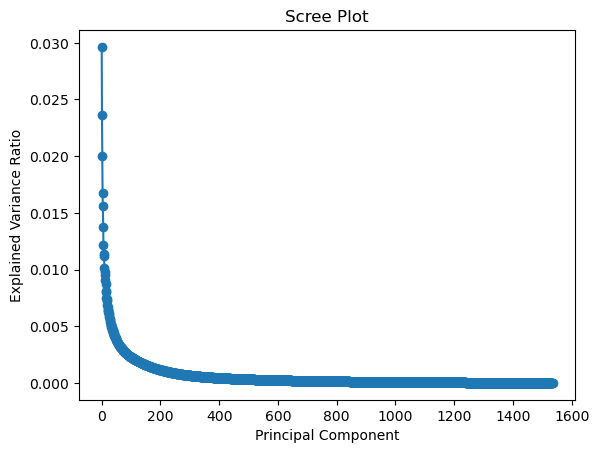

In [38]:
pca = PCA(n_components=None)
pca.fit(esdf)

plt.plot(pca.explained_variance_ratio_, marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.show()

# cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
# plt.plot(cumulative_variance, marker='o')
# plt.xlabel('Number of Components')
# plt.ylabel('Cumulative Explained Variance')
# plt.title('Cumulative Explained Variance')
# plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
# plt.legend()
# plt.show()

# eigenvalues = pca.explained_variance_
# ideal_dim = sum(eigenvalues > 1)
# print(f"Ideal dimensions (Kaiser Criterion): {ideal_dim}")

In [39]:
pca = PCA(n_components=5)
re = pca.fit_transform(esdf)
redf = pd.DataFrame(re)
redf.columns = [f'{i}' for i in range(redf.shape[1])]
lsdf.shape, redf.shape

((24591, 134), (24591, 5))

In [40]:
from sklearn.linear_model import Lasso
X = np.array(lsdf)  
y = np.array(redf)  
# Fit Lasso for each embedding dimension
lasso = Lasso(alpha=0.01)  
lasso.fit(X, y[:, 0])  
coefficients = lasso.coef_
key_features = []

for i in range(y.shape[1]):
    lasso = Lasso(alpha=0.5)  # Adjust alpha as needed
    lasso.fit(X, y[:, i])
    coefficients = lasso.coef_
    key_features.append(coefficients)

liwc_feature_names = ldf.columns

# Get non-zero coefficients for the first embedding dimension
non_zero_indices = np.where(coefficients != 0)[0]
key_liwc_features = [liwc_feature_names[i] for i in non_zero_indices]
print("Key LIWC Features:", key_liwc_features)

Key LIWC Features: ['Authentic', 'i', 'shehe', 'cogproc', 'tone_neg', 'conflict', 'Culture', 'politic', 'leisure', 'work', 'money', 'health', 'substances', 'food', 'space', 'time', 'focuspresent', 'anger', 'Arousal']


Highly Important LIWC Features: ['Authentic', 'i', 'shehe', 'cogproc', 'tone_neg', 'conflict', 'Culture', 'politic', 'leisure', 'work', 'money', 'health', 'substances', 'food', 'space', 'time', 'focuspresent', 'anger', 'Arousal']


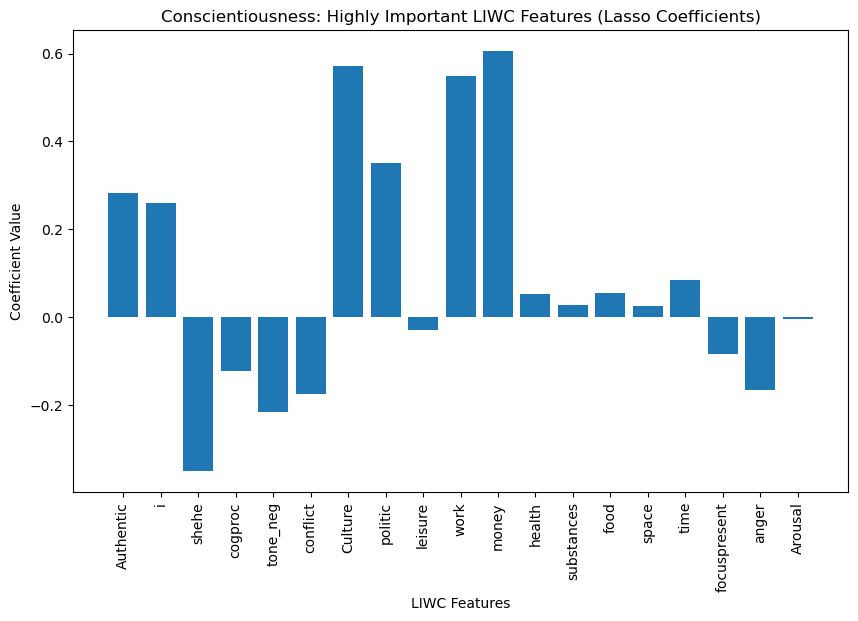

In [41]:

# plt.figure(figsize=(10, 6))
# plt.bar(range(len(coefficients)), coefficients)
# plt.xticks(range(len(coefficients)), liwc_feature_names, rotation=90)
# plt.xlabel("LIWC Features")
# plt.ylabel("Coefficient Value")
# plt.title("Lasso Coefficients for LIWC Features")
# plt.show()

# Assuming `coefficients` is the array of Lasso coefficients
highly_important_indices = np.where(np.abs(coefficients) > 0)[0]
highly_important_features = [liwc_feature_names[i] for i in highly_important_indices]

print("Highly Important LIWC Features:", highly_important_features)

plt.figure(figsize=(10, 6))
plt.bar(range(len(highly_important_indices)), coefficients[highly_important_indices])
plt.xticks(range(len(highly_important_indices)), [liwc_feature_names[i] for i in highly_important_indices], rotation=90)
plt.xlabel("LIWC Features")
plt.ylabel("Coefficient Value")
plt.title(f"{traits[target]}: Highly Important LIWC Features (Lasso Coefficients)")
# plt.savefig(f'{target}_liwc.png')
plt.show()

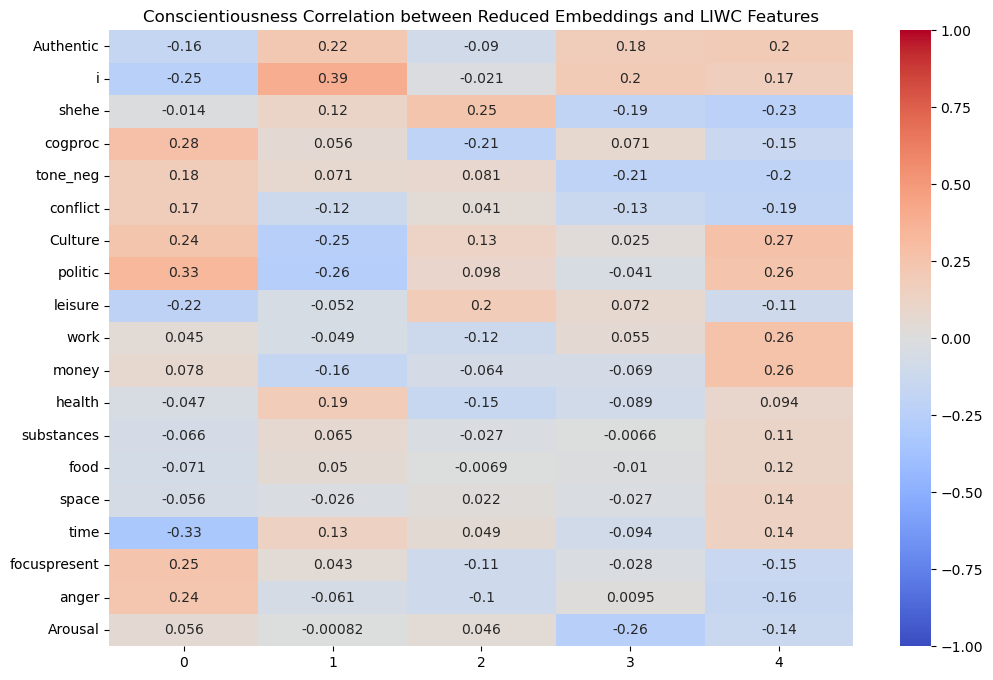

In [42]:
final_df = pd.concat([ldf[key_liwc_features], redf], axis=1)
# Compute correlation matrix
correlation_matrix = final_df.corr(method='pearson') 
embedding_liwc_corr = correlation_matrix.loc[key_liwc_features, redf.columns]


plt.figure(figsize=(12, 8))
sns.heatmap(embedding_liwc_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title(f"{traits[target]} Correlation between Reduced Embeddings and LIWC Features")
# plt.savefig(f'{target}.png')
plt.show()